<a href="https://colab.research.google.com/github/Shahadat-Karim/CNN-Development-Assignment/blob/main/Group_8_Final%20Project_(UTKFace)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTKFace: Classification & Regression


**Dataset**: [UTKFace on Kaggle](https://www.kaggle.com/datasets/jangedoo/utkface-new)

**Tasks**:
- **Classification**: Gender (0=Female, 1=Male)
- **Regression**: Age (continuous, 0–116)

**Models**: VGG16 & ResNet50 (both tasks) + Bonus Multi-Task

**Run on GPU**: Runtime → Change runtime type → GPU

In [1]:
import os
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/ 2>/dev/null || echo 'Please upload kaggle.json first!'
!chmod 600 ~/.kaggle/kaggle.json

# Download and extract
!kaggle datasets download -d jangedoo/utkface-new -q
!unzip -q utkface-new.zip -d /content/utkface_data
!rm utkface-new.zip

print("\nDataset download complete!")
print("Files in /content/utkface_data:")
!ls -la /content/utkface_data

Please upload kaggle.json first!
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors

Dataset download complete!
Files in /content/utkface_data:
total 2240
drwxr-xr-x 5 root root    4096 May 19 15:31 .
drwxr-xr-x 1 root root    4096 May 19 15:31 ..
drwxr-xr-x 2 root root  671744 May 19 15:31 crop_part1
drwxr-xr-x 2 root root 1609728 May 19 15:31 UTKFace
drwxr-xr-x 4 root root    4096 May 19 15:31 utkface_aligned_cropped


In [4]:

#VERIFY DATASET & SET PATHS

import os

possible_paths = [
    '/content/utkface_data/UTKFace',
    '/content/utkface_data/utkcropped/utkcropped',
    '/content/utkface_data/crop_part1',
    '/content/UTKFace',
]

DATA_DIR = None
for p in possible_paths:
    if os.path.exists(p) and os.path.isdir(p):
        files = [f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if len(files) > 100:  # Sanity check: should have thousands
            DATA_DIR = p
            print(f"✓ Found {len(files)} images at: {p}")
            break

if DATA_DIR is None:
    print("⚠ Auto-detect failed. Checking /content/utkface_data structure...")
    for root, dirs, files in os.walk('/content/utkface_data'):
        imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if len(imgs) > 100:
            DATA_DIR = root
            print(f"✓ Found {len(imgs)} images at: {root}")
            break

if DATA_DIR is None:
    raise FileNotFoundError("\nCould not find UTKFace images. \
    Please check that the dataset was extracted properly. \
    The folder should contain .jpg files like '1_0_0_20170109150557335.jpg'")

print(f"\n DATA_DIR set to: {DATA_DIR}")
print(f"Total files: {len(os.listdir(DATA_DIR))}")

✓ Found 23708 images at: /content/utkface_data/UTKFace

 DATA_DIR set to: /content/utkface_data/UTKFace
Total files: 23708


In [3]:

#IMPORTS


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.model_selection import train_test_split
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch.manual_seed(42)
np.random.seed(42)

Device: cuda
GPU: Tesla T4


In [5]:

#PARSE FILENAMES → age,gender,race,datetime.jpg

def parse_utkface(filename):
    try:
        parts = filename.split('_')
        if len(parts) < 4:
            return None
        return {
            'filename': filename,
            'age': int(parts[0]),
            'gender': int(parts[1]),      # 0=Female, 1=Male
            'race': int(parts[2]),
            'path': os.path.join(DATA_DIR, filename)
        }
    except:
        return None

records = []
for fname in os.listdir(DATA_DIR):
    if fname.lower().endswith(('.jpg','.jpeg','.png')):
        rec = parse_utkface(fname)
        if rec:
            records.append(rec)

df = pd.DataFrame(records)
print(f"Valid samples: {len(df)}")
print(df.head())
print(f"\nGender: {df['gender'].value_counts().sort_index().to_dict()}")
print(f"\nAge stats:\n{df['age'].describe()}")

Valid samples: 23705
                                filename  age  gender  race  \
0  30_0_0_20170104164938536.jpg.chip.jpg   30       0     0   
1  18_1_0_20170109213550274.jpg.chip.jpg   18       1     0   
2  33_1_3_20170104235051234.jpg.chip.jpg   33       1     3   
3  25_1_2_20170104021412148.jpg.chip.jpg   25       1     2   
4   1_1_2_20161219161751262.jpg.chip.jpg    1       1     2   

                                                path  
0  /content/utkface_data/UTKFace/30_0_0_201701041...  
1  /content/utkface_data/UTKFace/18_1_0_201701092...  
2  /content/utkface_data/UTKFace/33_1_3_201701042...  
3  /content/utkface_data/UTKFace/25_1_2_201701040...  
4  /content/utkface_data/UTKFace/1_1_2_2016121916...  

Gender: {0: 12391, 1: 11314}

Age stats:
count    23705.000000
mean        33.300907
std         19.885708
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


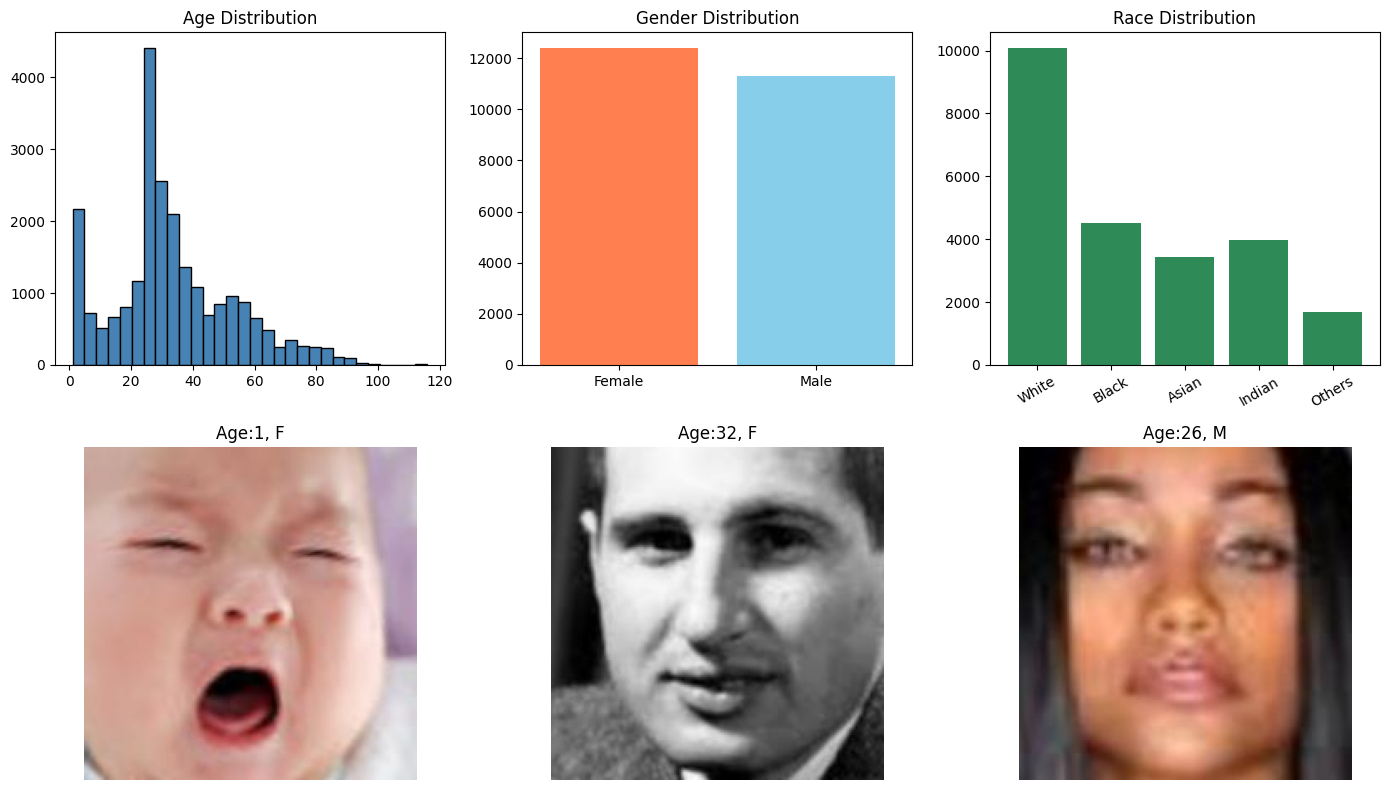

In [7]:

#DATASET VISUALIZATION


fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0,0].hist(df['age'], bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')

g = df['gender'].value_counts().sort_index()
axes[0,1].bar(['Female','Male'], g.values, color=['coral','skyblue'])
axes[0,1].set_title('Gender Distribution')

r = df['race'].value_counts().sort_index()
axes[0,2].bar(['White','Black','Asian','Indian','Others'], r.values, color='seagreen')
axes[0,2].set_title('Race Distribution')
axes[0,2].tick_params(axis='x', rotation=30)

for i, idx in enumerate(np.random.choice(len(df), 3, replace=False)):
    img = Image.open(df.iloc[idx]['path'])
    axes[1,i].imshow(img)
    axes[1,i].set_title(f"Age:{df.iloc[idx]['age']}, {'M' if df.iloc[idx]['gender'] else 'F'}")
    axes[1,i].axis('off')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150)
plt.show()

In [10]:

#TRAIN / VAL / TEST SPLIT


train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['gender'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['gender'])

print(f"Train:{len(train_df)} | Val:{len(val_df)} | Test:{len(test_df)}")

Train:16593 | Val:3556 | Test:3556


In [11]:

#PYTORCH DATASETS & DATALOADERS

IMG_SIZE = 224
BATCH_SIZE = 32

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class UTKDataset(Dataset):
    def __init__(self, df, transform=None, task='both'):
        self.df = df.reset_index(drop=True)
        self.tf = transform
        self.task = task
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.tf: img = self.tf(img)
        gender = torch.tensor(row['gender'], dtype=torch.long)
        age = torch.tensor(row['age'], dtype=torch.float32)
        if self.task == 'classification': return img, gender
        elif self.task == 'regression': return img, age
        else: return img, gender, age

# Classification loaders
tr_c = DataLoader(UTKDataset(train_df, train_tf, 'classification'), BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
va_c = DataLoader(UTKDataset(val_df, val_tf, 'classification'), BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
te_c = DataLoader(UTKDataset(test_df, val_tf, 'classification'), BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Regression loaders
tr_r = DataLoader(UTKDataset(train_df, train_tf, 'regression'), BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
va_r = DataLoader(UTKDataset(val_df, val_tf, 'regression'), BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
te_r = DataLoader(UTKDataset(test_df, val_tf, 'regression'), BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders ready!")

DataLoaders ready!


In [12]:

#MODEL DEFINITIONS


class VGGCls(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = models.vgg16(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone.classifier[6] = nn.Linear(self.backbone.classifier[6].in_features, 2)
    def forward(self, x):
        return self.backbone(x)
    def get_features(self, x):
        x = self.backbone.features(x)
        x = self.backbone.avgpool(x)
        return torch.flatten(x, 1)

class VGGReg(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = models.vgg16(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone.classifier[6] = nn.Linear(self.backbone.classifier[6].in_features, 1)
    def forward(self, x):
        return self.backbone(x).squeeze(1)
    def get_features(self, x):
        x = self.backbone.features(x)
        x = self.backbone.avgpool(x)
        return torch.flatten(x, 1)

class ResCls(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 2)
    def forward(self, x):
        return self.backbone(x)
    def get_features(self, x):
        x = self.backbone.conv1(x); x = self.backbone.bn1(x); x = self.backbone.relu(x); x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x); x = self.backbone.layer2(x); x = self.backbone.layer3(x); x = self.backbone.layer4(x)
        return x

class ResReg(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 1)
    def forward(self, x):
        return self.backbone(x).squeeze(1)
    def get_features(self, x):
        x = self.backbone.conv1(x); x = self.backbone.bn1(x); x = self.backbone.relu(x); x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x); x = self.backbone.layer2(x); x = self.backbone.layer3(x); x = self.backbone.layer4(x)
        return x

print("Models defined!")

Models defined!


In [13]:

#TRAINING UTILITIES


def train_cls(model, tr_loader, va_loader, epochs=25, lr=1e-4, name='model'):
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', patience=3)
    best = 0.0
    hist = {'t_loss':[],'t_acc':[],'v_loss':[],'v_acc':[]}
    for ep in range(epochs):
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for imgs, lbls in tqdm(tr_loader, desc=f'Ep{ep+1}/{epochs} [Tr]'):
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad()
            out = model(imgs)
            loss = crit(out, lbls)
            loss.backward()
            opt.step()
            tl += loss.item()*imgs.size(0)
            tc += (out.argmax(1)==lbls).sum().item()
            tt += lbls.size(0)
        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in va_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                vl += crit(out, lbls).item()*imgs.size(0)
                vc += (out.argmax(1)==lbls).sum().item()
                vt += lbls.size(0)
        ta, va = tc/tt, vc/vt
        tl, vl = tl/tt, vl/vt
        hist['t_loss'].append(tl); hist['t_acc'].append(ta); hist['v_loss'].append(vl); hist['v_acc'].append(va)
        print(f'Ep{ep+1}: TrLoss={tl:.4f} TrAcc={ta:.4f} VaLoss={vl:.4f} VaAcc={va:.4f}')
        sched.step(va)
        if va > best:
            best = va
            torch.save(model.state_dict(), f'{name}_best.pth')
            print(f'  -> Saved (va_acc={va:.4f})')
    return hist

def train_reg(model, tr_loader, va_loader, epochs=25, lr=1e-4, name='model'):
    model = model.to(device)
    crit = nn.MSELoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=3)
    best = float('inf')
    hist = {'t_loss':[],'v_loss':[],'v_mae':[]}
    for ep in range(epochs):
        model.train()
        tl, tt = 0.0, 0
        for imgs, tgt in tqdm(tr_loader, desc=f'Ep{ep+1}/{epochs} [Tr]'):
            imgs, tgt = imgs.to(device), tgt.to(device)
            opt.zero_grad()
            out = model(imgs)
            loss = crit(out, tgt)
            loss.backward()
            opt.step()
            tl += loss.item()*imgs.size(0)
            tt += tgt.size(0)
        model.eval()
        vl, vm, vt = 0.0, 0.0, 0
        with torch.no_grad():
            for imgs, tgt in va_loader:
                imgs, tgt = imgs.to(device), tgt.to(device)
                out = model(imgs)
                vl += crit(out, tgt).item()*imgs.size(0)
                vm += (out-tgt).abs().sum().item()
                vt += tgt.size(0)
        tl, vl, vm = tl/tt, vl/vt, vm/vt
        hist['t_loss'].append(tl); hist['v_loss'].append(vl); hist['v_mae'].append(vm)
        print(f'Ep{ep+1}: TrLoss={tl:.4f} VaLoss={vl:.4f} VaMAE={vm:.4f}')
        sched.step(vl)
        if vm < best:
            best = vm
            torch.save(model.state_dict(), f'{name}_best.pth')
            print(f'  -> Saved (va_mae={vm:.4f})')
    return hist

print("Eval functions ready!")

Eval functions ready!


In [14]:

#TRAIN VGG16 CLASSIFICATION

vgg_cls = VGGCls(pretrained=True)
# Freeze conv, train classifier
for p in vgg_cls.backbone.features.parameters(): p.requires_grad = False
for p in vgg_cls.backbone.classifier.parameters(): p.requires_grad = True

print("Training VGG Classification...")
h_vgg_c = train_cls(vgg_cls, tr_c, va_c, epochs=25, lr=1e-4, name='vgg_cls')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 71.9MB/s]


Training VGG Classification...


Ep1/25 [Tr]: 100%|██████████| 519/519 [01:46<00:00,  4.85it/s]


Ep1: TrLoss=0.3923 TrAcc=0.8193 VaLoss=0.3214 VaAcc=0.8585
  -> Saved (va_acc=0.8585)


...

Ep23: TrLoss=0.1234 TrAcc=0.9517 VaLoss=0.3162 VaAcc=0.9125
  -> Saved (va_acc=0.9125)


Ep24/25 [Tr]: 100%|██████████| 519/519 [01:52<00:00,  4.63it/s]


Ep24: TrLoss=0.1141 TrAcc=0.9561 VaLoss=0.3186 VaAcc=0.9117


Ep25/25 [Tr]: 100%|██████████| 519/519 [01:51<00:00,  4.65it/s]


Ep25: TrLoss=0.1113 TrAcc=0.9572 VaLoss=0.3280 VaAcc=0.9106


In [15]:

#TRAIN VGG16 REGRESSION


vgg_reg = VGGReg(pretrained=True)
for p in vgg_reg.backbone.features.parameters(): p.requires_grad = False
for p in vgg_reg.backbone.classifier.parameters(): p.requires_grad = True

print("Training VGG Regression...")
h_vgg_r = train_reg(vgg_reg, tr_r, va_r, epochs=25, lr=1e-4, name='vgg_reg')

Training VGG Regression...


Ep1/25 [Tr]: 100%|██████████| 519/519 [01:51<00:00,  4.65it/s]


Ep1: TrLoss=168.5604 VaLoss=114.9441 VaMAE=7.9411
  -> Saved (va_mae=7.9411)


Ep2/25 [Tr]: 100%|██████████| 519/519 [01:51<00:00,  4.65it/s]


Ep2: TrLoss=116.2348 VaLoss=104.9162 VaMAE=7.4389
  -> Saved (va_mae=7.4389)


...

Ep23: TrLoss=56.0921 VaLoss=85.4743 VaMAE=6.6060


Ep24/25 [Tr]: 100%|██████████| 519/519 [01:53<00:00,  4.59it/s]


Ep24: TrLoss=54.1541 VaLoss=85.2914 VaMAE=6.5710
  -> Saved (va_mae=6.5710)


Ep25/25 [Tr]: 100%|██████████| 519/519 [01:54<00:00,  4.55it/s]


Ep25: TrLoss=54.7546 VaLoss=85.3616 VaMAE=6.5735


In [16]:

#TRAIN RESNET50 CLASSIFICATION


res_cls = ResCls(pretrained=True)
for n, p in res_cls.backbone.named_parameters():
    p.requires_grad = ('layer4' in n or 'fc' in n)

print("Training ResNet Classification...")
h_res_c = train_cls(res_cls, tr_c, va_c, epochs=25, lr=1e-4, name='res_cls')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s]


Training ResNet Classification...


Ep1/25 [Tr]: 100%|██████████| 519/519 [01:35<00:00,  5.42it/s]


Ep1: TrLoss=0.3144 TrAcc=0.8601 VaLoss=0.2432 VaAcc=0.8976
  -> Saved (va_acc=0.8976)


...

Ep23: TrLoss=0.0356 TrAcc=0.9877 VaLoss=0.2728 VaAcc=0.9291


Ep24/25 [Tr]: 100%|██████████| 519/519 [01:36<00:00,  5.40it/s]


Ep24: TrLoss=0.0352 TrAcc=0.9867 VaLoss=0.2801 VaAcc=0.9280


Ep25/25 [Tr]: 100%|██████████| 519/519 [01:36<00:00,  5.40it/s]


Ep25: TrLoss=0.0346 TrAcc=0.9882 VaLoss=0.2782 VaAcc=0.9291


In [17]:

#TRAIN RESNET50 REGRESSION


res_reg = ResReg(pretrained=True)
for n, p in res_reg.backbone.named_parameters():
    p.requires_grad = ('layer4' in n or 'fc' in n)

print("Training ResNet Regression...")
h_res_r = train_reg(res_reg, tr_r, va_r, epochs=25, lr=1e-4, name='res_reg')

Training ResNet Regression...


Ep1/25 [Tr]: 100%|██████████| 519/519 [01:35<00:00,  5.42it/s]


Ep1: TrLoss=336.4290 VaLoss=85.5287 VaMAE=6.7945
  -> Saved (va_mae=6.7945)


Ep2/25 [Tr]: 100%|██████████| 519/519 [01:35<00:00,  5.41it/s]


Ep2: TrLoss=85.0449 VaLoss=73.9445 VaMAE=6.3104
  -> Saved (va_mae=6.3104)


...

Ep23: TrLoss=17.0398 VaLoss=53.2943 VaMAE=5.2134


Ep24/25 [Tr]: 100%|██████████| 519/519 [01:31<00:00,  5.64it/s]


Ep24: TrLoss=16.5440 VaLoss=53.5569 VaMAE=5.2022
  -> Saved (va_mae=5.2022)


Ep25/25 [Tr]: 100%|██████████| 519/519 [01:32<00:00,  5.62it/s]


Ep25: TrLoss=16.0082 VaLoss=53.8290 VaMAE=5.2244


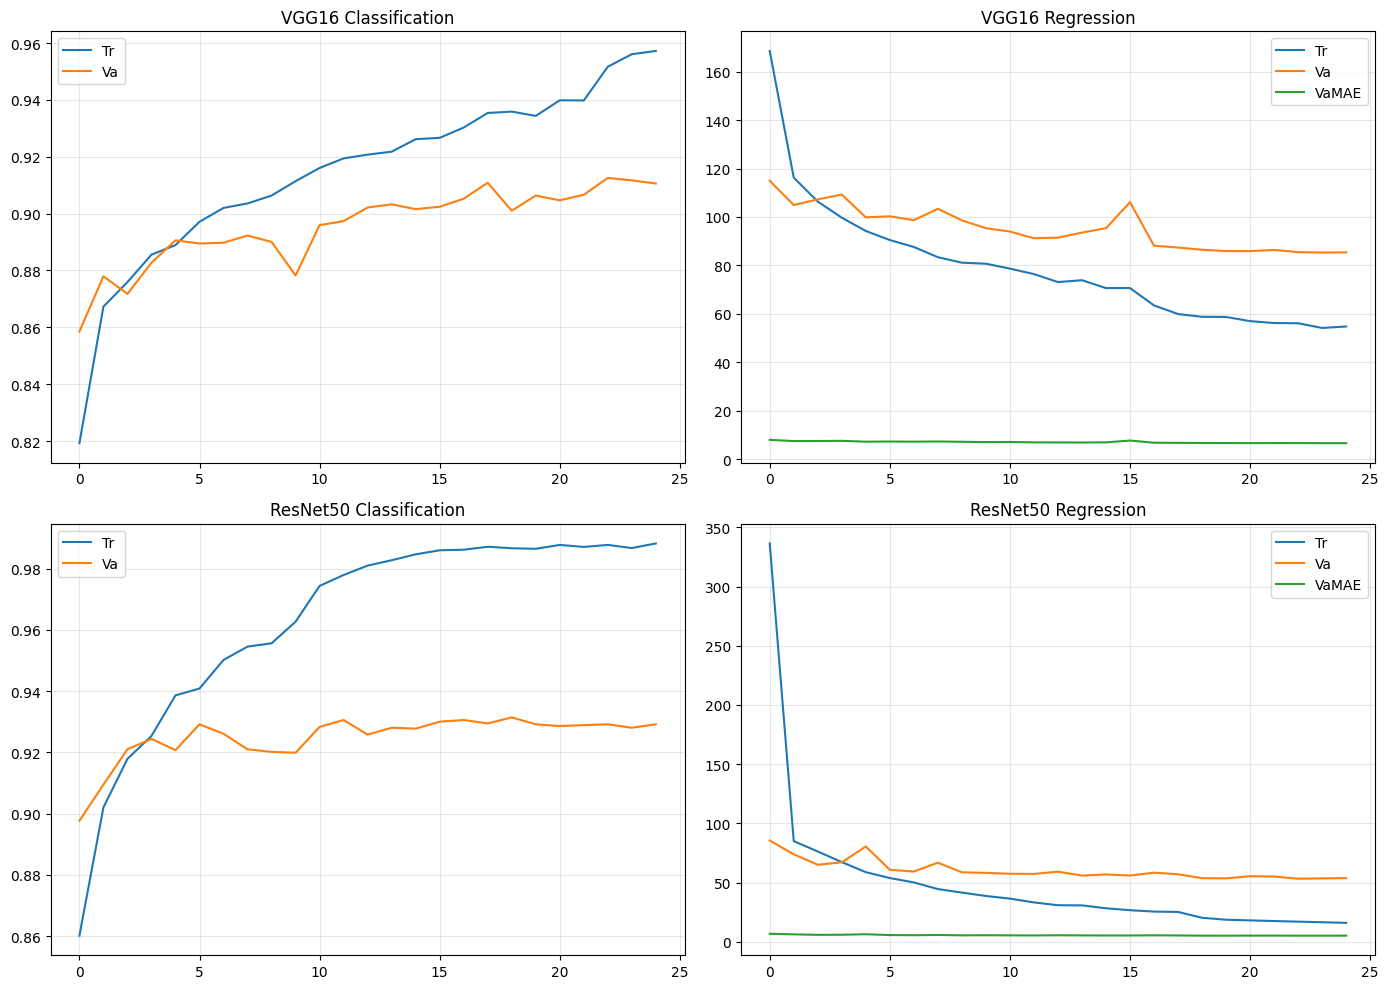

In [18]:

#PLOT TRAINING CURVES


fig, axes = plt.subplots(2,2, figsize=(14,10))

axes[0,0].plot(h_vgg_c['t_acc'], label='Tr'); axes[0,0].plot(h_vgg_c['v_acc'], label='Va')
axes[0,0].set_title('VGG16 Classification'); axes[0,0].legend(); axes[0,0].grid(True,alpha=0.3)

axes[0,1].plot(h_vgg_r['t_loss'], label='Tr'); axes[0,1].plot(h_vgg_r['v_loss'], label='Va'); axes[0,1].plot(h_vgg_r['v_mae'], label='VaMAE')
axes[0,1].set_title('VGG16 Regression'); axes[0,1].legend(); axes[0,1].grid(True,alpha=0.3)

axes[1,0].plot(h_res_c['t_acc'], label='Tr'); axes[1,0].plot(h_res_c['v_acc'], label='Va')
axes[1,0].set_title('ResNet50 Classification'); axes[1,0].legend(); axes[1,0].grid(True,alpha=0.3)

axes[1,1].plot(h_res_r['t_loss'], label='Tr'); axes[1,1].plot(h_res_r['v_loss'], label='Va'); axes[1,1].plot(h_res_r['v_mae'], label='VaMAE')
axes[1,1].set_title('ResNet50 Regression'); axes[1,1].legend(); axes[1,1].grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [19]:

# EVALUATION FUNCTIONS


def eval_cls(model, loader, name='Model'):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out = model(imgs.to(device))
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(lbls.numpy())
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n=== {name} Classification ===")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['F','M'], yticklabels=['F','M'])
    plt.title(f'{name} Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Pred')
    plt.tight_layout(); plt.savefig(f'{name.lower().replace(" ","_")}_cm.png', dpi=150); plt.show()
    return {'acc':acc,'f1':f1,'cm':cm}

def eval_reg(model, loader, name='Model'):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, tgt in loader:
            y_pred.extend(model(imgs.to(device)).cpu().numpy())
            y_true.extend(tgt.numpy())
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== {name} Regression ===")
    print(f"MSE:{mse:.4f} RMSE:{rmse:.4f} MAE:{mae:.4f} R²:{r2:.4f}")
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.4, s=20)
    plt.plot([0,100],[0,100],'r--',lw=2)
    plt.xlabel('True Age'); plt.ylabel('Pred Age')
    plt.title(f'{name} True vs Pred'); plt.xlim(0,100); plt.ylim(0,100)
    plt.grid(True,alpha=0.3); plt.tight_layout()
    plt.savefig(f'{name.lower().replace(" ","_")}_scatter.png', dpi=150); plt.show()
    return {'mse':mse,'rmse':rmse,'mae':mae,'r2':r2}

print("Eval functions ready!")

Eval functions ready!



=== VGG16 Classification ===
Accuracy: 0.9049 | F1: 0.9049


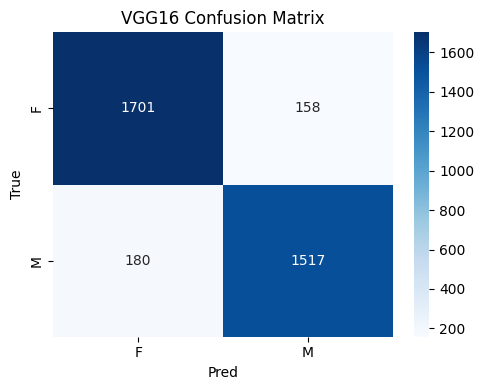


=== ResNet50 Classification ===
Accuracy: 0.9348 | F1: 0.9348


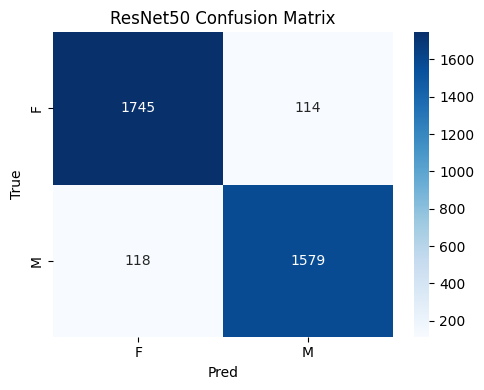


=== VGG16 Regression ===
MSE:79.4957 RMSE:8.9160 MAE:6.4229 R²:0.7988


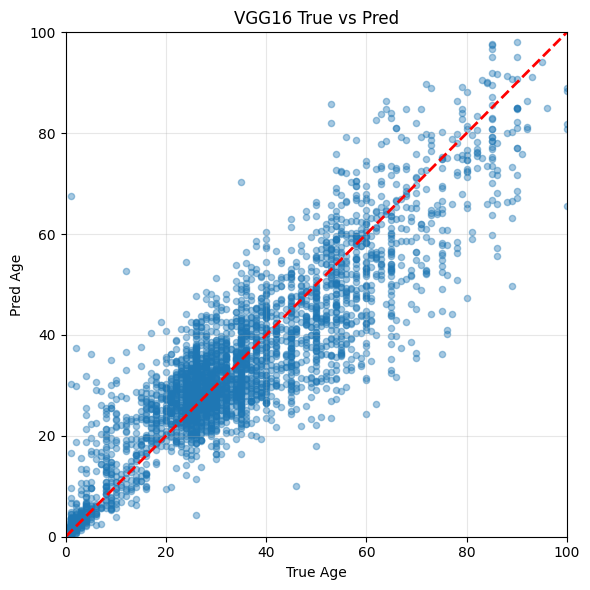


=== ResNet50 Regression ===
MSE:52.6308 RMSE:7.2547 MAE:5.0865 R²:0.8668


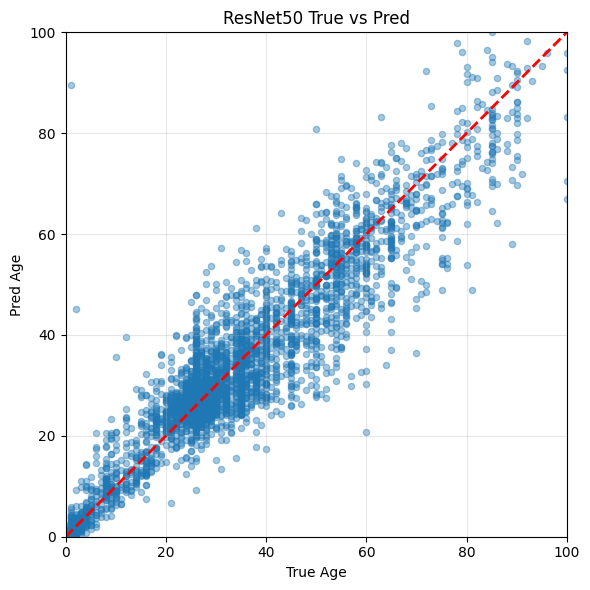

In [20]:

#LOAD BEST WEIGHTS & EVALUATE


vgg_cls = VGGCls(pretrained=True).to(device)
vgg_cls.load_state_dict(torch.load('vgg_cls_best.pth'))

vgg_reg = VGGReg(pretrained=True).to(device)
vgg_reg.load_state_dict(torch.load('vgg_reg_best.pth'))

res_cls = ResCls(pretrained=True).to(device)
res_cls.load_state_dict(torch.load('res_cls_best.pth'))

res_reg = ResReg(pretrained=True).to(device)
res_reg.load_state_dict(torch.load('res_reg_best.pth'))

r_vgg_c = eval_cls(vgg_cls, te_c, 'VGG16')
r_res_c = eval_cls(res_cls, te_c, 'ResNet50')
r_vgg_r = eval_reg(vgg_reg, te_r, 'VGG16')
r_res_r = eval_reg(res_reg, te_r, 'ResNet50')

In [21]:

#GRAD-CAM IMPLEMENTATION


def set_relu_inplace(model, inplace=False):
    """Fix inplace ReLU conflict with backward hooks"""
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            module.inplace = inplace

class GradCAM:
    def __init__(self, model, layer_name):
        self.model = model
        self.grads = None
        self.acts = None
        layer = dict(model.named_modules())[layer_name]
        layer.register_forward_hook(self._save_act)
        layer.register_full_backward_hook(self._save_grad)
    def _save_act(self, m, inp, out): self.acts = out.detach()
    def _save_grad(self, m, grad_in, grad_out): self.grads = grad_out[0].detach()
    def gen(self, img, cls=None):
        self.model.eval()
        img = img.unsqueeze(0).to(device)
        out = self.model(img)
        self.model.zero_grad()
        if out.dim() == 1:
            out.backward(torch.ones_like(out))
        else:
            if cls is None: cls = out.argmax(1).item()
            oh = torch.zeros_like(out); oh[0,cls] = 1
            out.backward(gradient=oh)
        w = self.grads.mean(dim=[0,2,3], keepdim=True)
        hm = (w * self.acts).sum(dim=1).squeeze().cpu().numpy()
        hm = np.maximum(hm, 0)
        hm /= hm.max() + 1e-8
        return hm

def show_gradcam(model, ds, gc, name, task, n=3):
    idxs = np.random.choice(len(ds), n, replace=False)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n==1: axes = axes.reshape(1,-1)
    for i, idx in enumerate(idxs):
        img, lbl = ds[idx]
        hm = gc.gen(img)
        img_np = img.cpu().numpy().transpose(1,2,0)
        img_np = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
        img_np = np.clip(img_np, 0, 1)
        hm_r = cv2.resize(hm, (IMG_SIZE, IMG_SIZE))
        hm_c = cv2.applyColorMap(np.uint8(255*hm_r), cv2.COLORMAP_JET)
        hm_c = cv2.cvtColor(hm_c, cv2.COLOR_BGR2RGB)
        ov = (hm_c * 0.4 + img_np*255 * 0.6).astype(np.uint8)
        model.eval()
        with torch.no_grad():
            out = model(img.unsqueeze(0).to(device))
            if task == 'classification':
                pr = 'M' if out.argmax(1).item() else 'F'
                tr = 'M' if lbl.item() else 'F'
                tit = f'Pred:{pr} True:{tr}'
            else:
                tit = f'Pred:{out.item():.1f} True:{lbl.item():.1f}'
        axes[i,0].imshow(img_np); axes[i,0].set_title('Original'); axes[i,0].axis('off')
        axes[i,1].imshow(hm_c); axes[i,1].set_title('Heatmap'); axes[i,1].axis('off')
        axes[i,2].imshow(ov); axes[i,2].set_title(f'Overlay\n{tit}'); axes[i,2].axis('off')
    plt.suptitle(f'{name} Grad-CAM ({task})', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{name.lower().replace(" ","_")}_gradcam_{task}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Grad-CAM ready!")

Grad-CAM ready!


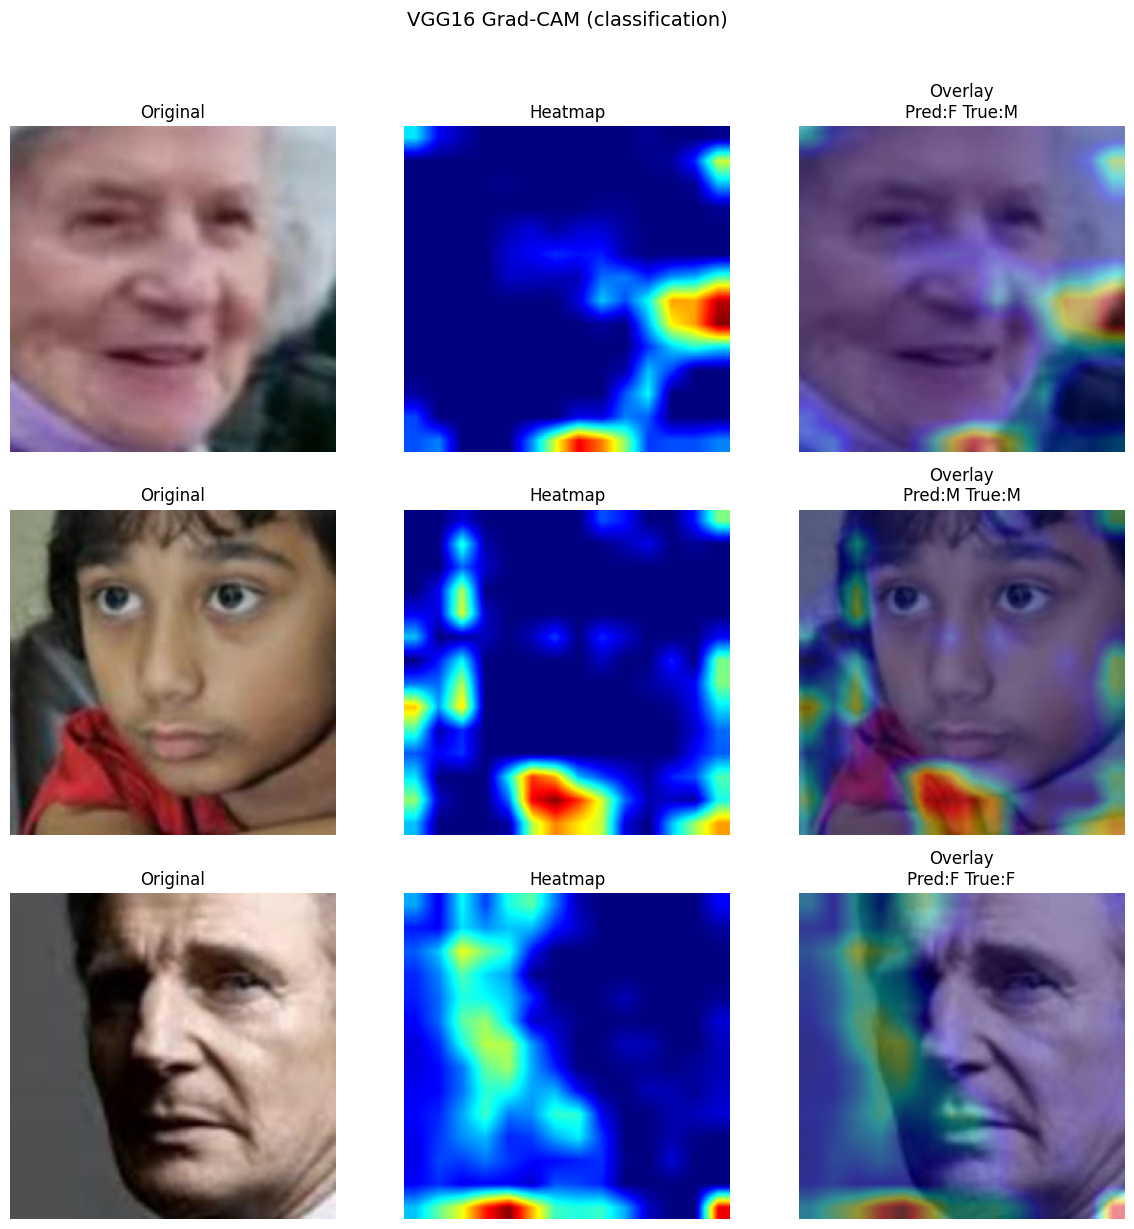

In [22]:
# VGG16 Classification Grad-CAM
set_relu_inplace(vgg_cls, inplace=False)
gc_vgg_c = GradCAM(vgg_cls, 'backbone.features.29')
show_gradcam(vgg_cls, te_c.dataset, gc_vgg_c, 'VGG16', 'classification')

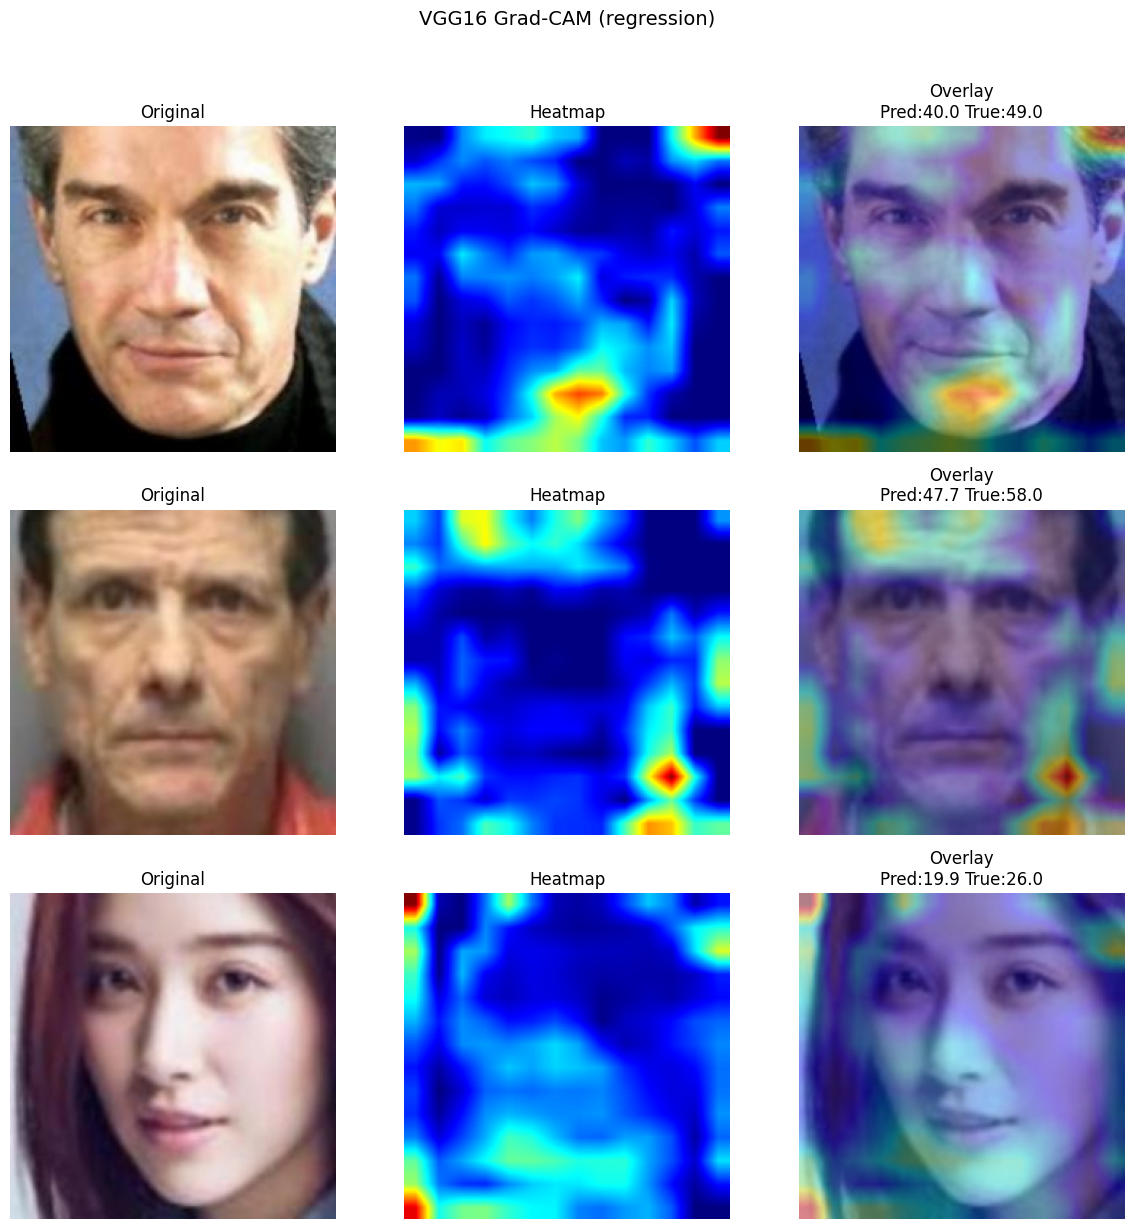

In [23]:
# VGG16 Regression Grad-CAM
set_relu_inplace(vgg_reg, inplace=False)
gc_vgg_r = GradCAM(vgg_reg, 'backbone.features.29')
show_gradcam(vgg_reg, te_r.dataset, gc_vgg_r, 'VGG16', 'regression')

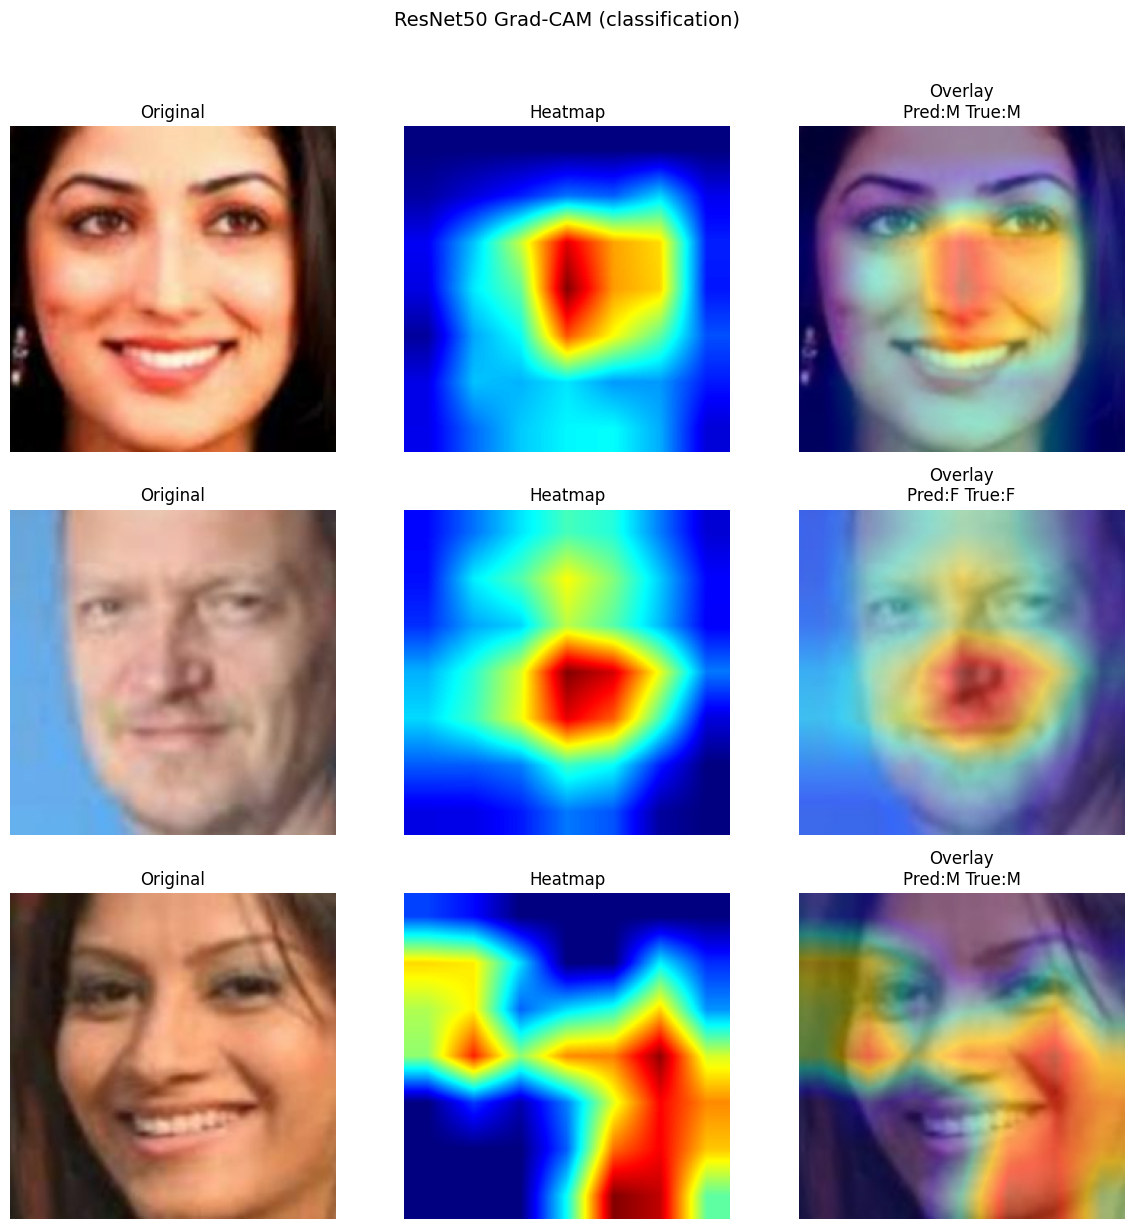

In [24]:
# ResNet50 Classification Grad-CAM
gc_res_c = GradCAM(res_cls, 'backbone.layer4.2.conv3')
show_gradcam(res_cls, te_c.dataset, gc_res_c, 'ResNet50', 'classification')

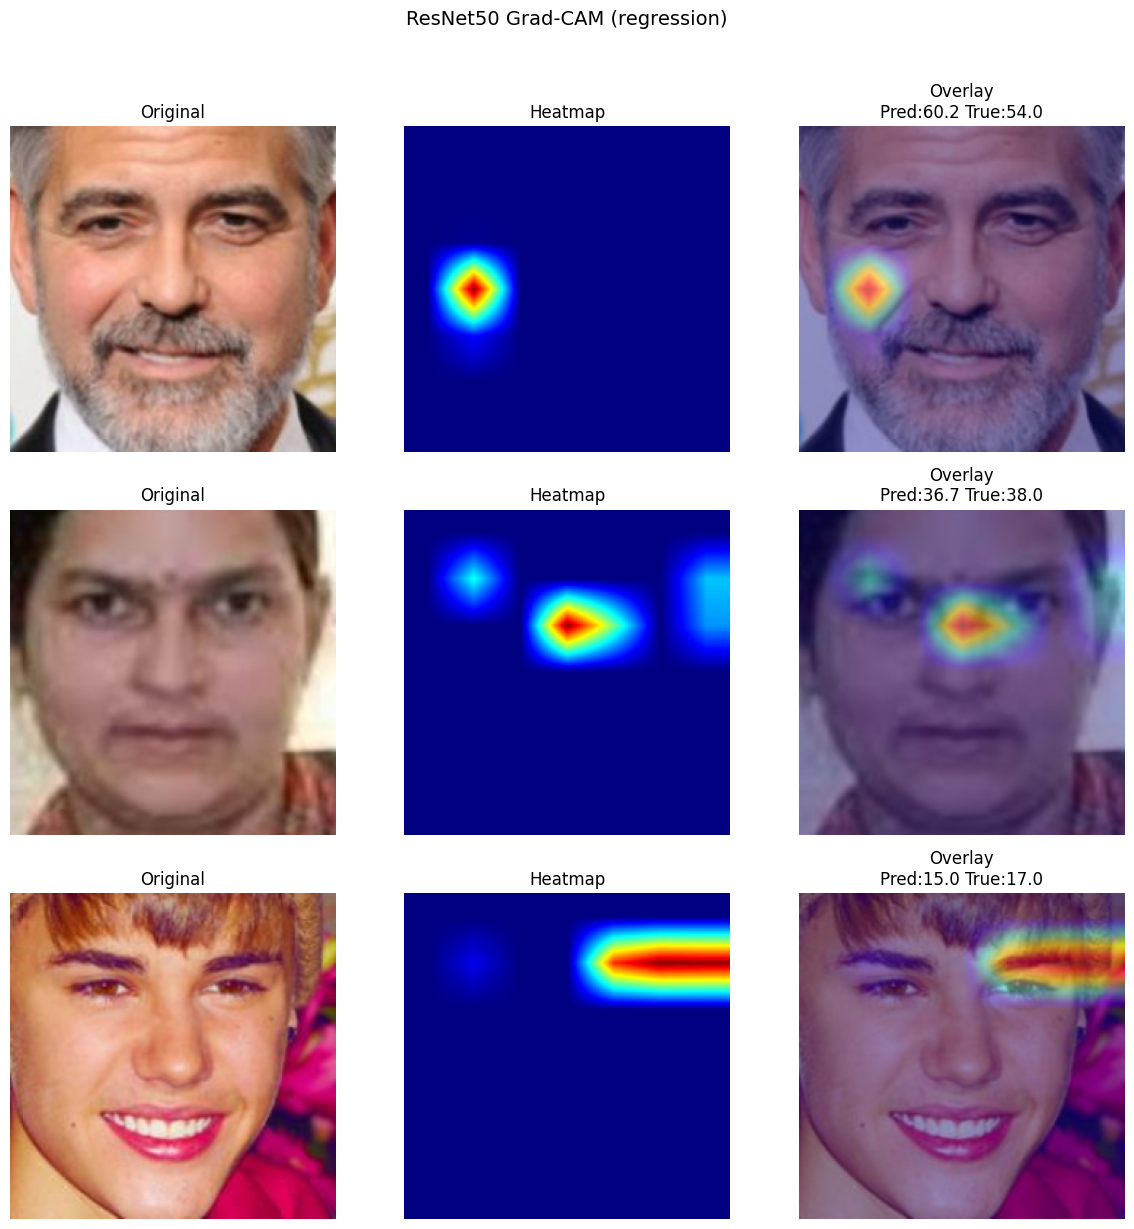

In [25]:
# ResNet50 Regression Grad-CAM
gc_res_r = GradCAM(res_reg, 'backbone.layer4.2.conv3')
show_gradcam(res_reg, te_r.dataset, gc_res_r, 'ResNet50', 'regression')

In [26]:

#COMPARISON TABLE


comp = {
    'Model': ['VGG16','VGG16','ResNet50','ResNet50'],
    'Task': ['Classification','Regression','Classification','Regression'],
    'Accuracy': [f"{r_vgg_c['acc']:.4f}",'-',f"{r_res_c['acc']:.4f}",'-'],
    'F1-Score': [f"{r_vgg_c['f1']:.4f}",'-',f"{r_res_c['f1']:.4f}",'-'],
    'RMSE': ['-',f"{r_vgg_r['rmse']:.4f}",'-',f"{r_res_r['rmse']:.4f}"],
    'MAE': ['-',f"{r_vgg_r['mae']:.4f}",'-',f"{r_res_r['mae']:.4f}"],
    'R²': ['-',f"{r_vgg_r['r2']:.4f}",'-',f"{r_res_r['r2']:.4f}"]
}
comp_df = pd.DataFrame(comp)
print(comp_df.to_string(index=False))
comp_df.to_csv('comparison.csv', index=False)
comp_df.style.set_properties(**{'text-align':'center'})

   Model           Task Accuracy F1-Score   RMSE    MAE     R²
   VGG16 Classification   0.9049   0.9049      -      -      -
   VGG16     Regression        -        - 8.9160 6.4229 0.7988
ResNet50 Classification   0.9348   0.9348      -      -      -
ResNet50     Regression        -        - 7.2547 5.0865 0.8668


,Model,Task,Accuracy,F1-Score,RMSE,MAE,R²
0,VGG16,Classification,0.9049,0.9049,-,-,-
1,VGG16,Regression,-,-,8.9160,6.4229,0.7988
2,ResNet50,Classification,0.9348,0.9348,-,-,-
3,ResNet50,Regression,-,-,7.2547,5.0865,0.8668


# Bonus: Multi-Task ResNet50 (+1 Mark)
Shared backbone, two heads: gender classification + age regression.

In [27]:

#MULTI-TASK MODEL

class MultiResNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        feat = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.cls_head = nn.Sequential(nn.Linear(feat,256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256,2))
        self.reg_head = nn.Sequential(nn.Linear(feat,256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256,1))
    def forward(self, x):
        f = self.backbone(x)
        return self.cls_head(f), self.reg_head(f).squeeze(1)
    def get_features(self, x):
        x = self.backbone.conv1(x); x = self.backbone.bn1(x); x = self.backbone.relu(x); x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x); x = self.backbone.layer2(x); x = self.backbone.layer3(x); x = self.backbone.layer4(x)
        return x

tr_mt = DataLoader(UTKDataset(train_df, train_tf, 'both'), BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
va_mt = DataLoader(UTKDataset(val_df, val_tf, 'both'), BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
te_mt = DataLoader(UTKDataset(test_df, val_tf, 'both'), BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

def train_mt(model, tr, va, epochs=25, lr=1e-4):
    model = model.to(device)
    c_crit, r_crit = nn.CrossEntropyLoss(), nn.MSELoss()
    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=3)
    best = float('inf')
    hist = {'tl':[],'vl':[],'va':[],'vm':[]}
    for ep in range(epochs):
        model.train(); tl, tt = 0.0, 0
        for imgs, g, a in tqdm(tr, desc=f'MT Ep{ep+1}/{epochs}'):
            imgs, g, a = imgs.to(device), g.to(device), a.to(device)
            opt.zero_grad()
            cg, ra = model(imgs)
            loss = c_crit(cg, g) + r_crit(ra, a)
            loss.backward(); opt.step()
            tl += loss.item()*imgs.size(0); tt += imgs.size(0)
        model.eval(); vl, vc, vm, vt = 0.0, 0, 0.0, 0
        with torch.no_grad():
            for imgs, g, a in va:
                imgs, g, a = imgs.to(device), g.to(device), a.to(device)
                cg, ra = model(imgs)
                vl += (c_crit(cg,g)+r_crit(ra,a)).item()*imgs.size(0)
                vc += (cg.argmax(1)==g).sum().item()
                vm += (ra-a).abs().sum().item()
                vt += g.size(0)
        tl, vl, v_acc, vm = tl/tt, vl/vt, vc/vt, vm/vt   # <-- FIXED: renamed va to v_acc
        hist['tl'].append(tl); hist['vl'].append(vl); hist['va'].append(v_acc); hist['vm'].append(vm)
        print(f'Ep{ep+1}: TrLoss={tl:.4f} VaLoss={vl:.4f} VaAcc={v_acc:.4f} VaMAE={vm:.4f}')
        sched.step(vl)
        if vl < best:
            best = vl; torch.save(model.state_dict(), 'mt_best.pth'); print('  -> Saved')
    return hist

mt = MultiResNet(pretrained=True)
for n, p in mt.backbone.named_parameters():
    p.requires_grad = ('layer4' in n)
print("Training Multi-Task...")
h_mt = train_mt(mt, tr_mt, va_mt, epochs=25, lr=1e-4)

Training Multi-Task...


MT Ep1/25: 100%|██████████| 519/519 [01:33<00:00,  5.57it/s]


Ep1: TrLoss=184.0708 VaLoss=85.0516 VaAcc=0.6291 VaMAE=6.8027
  -> Saved


MT Ep2/25: 100%|██████████| 519/519 [01:32<00:00,  5.63it/s]


Ep2: TrLoss=89.7925 VaLoss=69.8951 VaAcc=0.8015 VaMAE=6.1387
  -> Saved


...

Ep23: TrLoss=22.3670 VaLoss=52.2258 VaAcc=0.8892 VaMAE=5.1210


MT Ep24/25: 100%|██████████| 519/519 [01:33<00:00,  5.55it/s]


Ep24: TrLoss=22.4135 VaLoss=52.6338 VaAcc=0.8864 VaMAE=5.1075


MT Ep25/25: 100%|██████████| 519/519 [01:33<00:00,  5.57it/s]


Ep25: TrLoss=22.3682 VaLoss=52.3496 VaAcc=0.8878 VaMAE=5.0993


In [28]:

#EVALUATE MULTI-TASK


mt = MultiResNet(pretrained=True).to(device)
mt.load_state_dict(torch.load('mt_best.pth'))
mt.eval()
gt, gp, at, ap = [], [], [], []
with torch.no_grad():
    for imgs, g, a in te_mt:
        cg, ra = mt(imgs.to(device))
        gp.extend(cg.argmax(1).cpu().numpy()); gt.extend(g.numpy())
        ap.extend(ra.cpu().numpy()); at.extend(a.numpy())

mt_acc = accuracy_score(gt, gp)
mt_f1 = f1_score(gt, gp, average='weighted')
mt_mse = mean_squared_error(at, ap)
mt_rmse = np.sqrt(mt_mse)
mt_mae = mean_absolute_error(at, ap)
mt_r2 = r2_score(at, ap)

print(f"Multi-Task Cls Acc: {mt_acc:.4f} | F1: {mt_f1:.4f}")
print(f"Multi-Task Reg MSE: {mt_mse:.4f} | RMSE: {mt_rmse:.4f} | MAE: {mt_mae:.4f} | R²: {mt_r2:.4f}")

Multi-Task Cls Acc: 0.8915 | F1: 0.8915
Multi-Task Reg MSE: 50.9710 | RMSE: 7.1394 | MAE: 5.0646 | R²: 0.8710


In [29]:

# FINAL COMPARISON WITH MULTI-TASK

final = {
    'Model': ['VGG16','VGG16','ResNet50','ResNet50','ResNet50-MT','ResNet50-MT'],
    'Task': ['Cls','Reg','Cls','Reg','Cls','Reg'],
    'Accuracy': [f"{r_vgg_c['acc']:.4f}",'-',f"{r_res_c['acc']:.4f}",'-',f"{mt_acc:.4f}",'-'],
    'F1': [f"{r_vgg_c['f1']:.4f}",'-',f"{r_res_c['f1']:.4f}",'-',f"{mt_f1:.4f}",'-'],
    'RMSE': ['-',f"{r_vgg_r['rmse']:.4f}",'-',f"{r_res_r['rmse']:.4f}",'-',f"{mt_rmse:.4f}"],
    'MAE': ['-',f"{r_vgg_r['mae']:.4f}",'-',f"{r_res_r['mae']:.4f}",'-',f"{mt_mae:.4f}"],
    'R²': ['-',f"{r_vgg_r['r2']:.4f}",'-',f"{r_res_r['r2']:.4f}",'-',f"{mt_r2:.4f}"]
}
final_df = pd.DataFrame(final)
print(final_df.to_string(index=False))
final_df.to_csv('final_comparison.csv', index=False)
final_df.style.set_properties(**{'text-align':'center'})

      Model Task Accuracy     F1   RMSE    MAE     R²
      VGG16  Cls   0.9049 0.9049      -      -      -
      VGG16  Reg        -      - 8.9160 6.4229 0.7988
   ResNet50  Cls   0.9348 0.9348      -      -      -
   ResNet50  Reg        -      - 7.2547 5.0865 0.8668
ResNet50-MT  Cls   0.8915 0.8915      -      -      -
ResNet50-MT  Reg        -      - 7.1394 5.0646 0.8710


,Model,Task,Accuracy,F1,RMSE,MAE,R²
0,VGG16,Cls,0.9049,0.9049,-,-,-
1,VGG16,Reg,-,-,8.9160,6.4229,0.7988
2,ResNet50,Cls,0.9348,0.9348,-,-,-
3,ResNet50,Reg,-,-,7.2547,5.0865,0.8668
4,ResNet50-MT,Cls,0.8915,0.8915,-,-,-
5,ResNet50-MT,Reg,-,-,7.1394,5.0646,0.8710


In [30]:

# DOWNLOAD ALL OUTPUTS


import os
from google.colab import files

# List of all files your notebook generated
output_files = [
    'vgg_cls_best.pth',
    'vgg_reg_best.pth',
    'res_cls_best.pth',
    'res_reg_best.pth',
    'mt_best.pth',
    'dataset_overview.png',
    'training_curves.png',
    'vgg16_cm.png',
    'resnet50_cm.png',
    'vgg16_scatter.png',
    'resnet50_scatter.png',
    'vgg16_gradcam_classification.png',
    'vgg16_gradcam_regression.png',
    'resnet50_gradcam_classification.png',
    'resnet50_gradcam_regression.png',
    'comparison.csv',
    'final_comparison.csv'
]

# Check which files actually exist
found = [f for f in output_files if os.path.exists(f)]
missing = [f for f in output_files if not os.path.exists(f)]

print(f"Found {len(found)} files to download:")
for f in found:
    size = os.path.getsize(f) / (1024*1024)  # MB
    print(f"  ✅ {f} ({size:.2f} MB)")

if missing:
    print(f"\nMissing {len(missing)} files (training may not have completed):")
    for f in missing:
        print(f"  ❌ {f}")

# Zip everything
if found:
    !zip -q project_outputs.zip {' '.join(found)}
    print(f"\n📦 Zipped into: project_outputs.zip ({os.path.getsize('project_outputs.zip')/1024/1024:.2f} MB)")
    files.download('project_outputs.zip')
    print("⬇️ Download started — check your browser's downloads folder")
else:
    print("No files found to download!")

Found 17 files to download:
  ✅ vgg_cls_best.pth (512.21 MB)
  ✅ vgg_reg_best.pth (512.19 MB)
  ✅ res_cls_best.pth (90.00 MB)
  ✅ res_reg_best.pth (89.99 MB)
  ✅ mt_best.pth (93.99 MB)
  ✅ dataset_overview.png (0.54 MB)
  ✅ training_curves.png (0.18 MB)
  ✅ vgg16_cm.png (0.03 MB)
  ✅ resnet50_cm.png (0.03 MB)
  ✅ vgg16_scatter.png (0.21 MB)
  ✅ resnet50_scatter.png (0.20 MB)
  ✅ vgg16_gradcam_classification.png (1.33 MB)
  ✅ vgg16_gradcam_regression.png (1.56 MB)
  ✅ resnet50_gradcam_classification.png (1.39 MB)
  ✅ resnet50_gradcam_regression.png (1.42 MB)
  ✅ comparison.csv (0.00 MB)
  ✅ final_comparison.csv (0.00 MB)

📦 Zipped into: project_outputs.zip (1210.55 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download started — check your browser's downloads folder


# Submission Checklist

| Output | File |
|--------|------|
| VGG Cls weights | `vgg_cls_best.pth` |
| VGG Reg weights | `vgg_reg_best.pth` |
| Res Cls weights | `res_cls_best.pth` |
| Res Reg weights | `res_reg_best.pth` |
| Multi-Task weights | `mt_best.pth` |
| Dataset viz | `dataset_overview.png` |
| Training curves | `training_curves.png` |
| Confusion matrices | `*_cm.png` |
| Regression scatter | `*_scatter.png` |
| Grad-CAM (4 models) | `*_gradcam_*.png` |
| Comparison tables | `comparison.csv`, `final_comparison.csv` |